# Partial Dependence Plots

The partial dependence plot (short PDP or PD plot) shows the marginal effect one or two features have on the predicted outcome of a machine learning model ([Friedman 2001](https://christophm.github.io/interpretable-ml-book/references.html#ref-friedman2001greedy)). A partial dependence plot can show whether the relationship between the target and a feature is linear, monotonic, or more complex.

- PDPs it is relatively quick.
- PDP assumes independence between the features, and can be misleading otherwise (e.g. when the model has many high order interactions).

### Examples

Due to the limits of human perception, the size of the set of input features of interest must be small (usually, one or two) thus the input features of interest are usually chosen among the most important features.

The figure below shows two one-way and one two-way partial dependence plots for the bike sharing dataset, with a [`HistGradientBoostingRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html#sklearn.ensemble.HistGradientBoostingRegressor "sklearn.ensemble.HistGradientBoostingRegressor"):

![Figure: 1-way vs 2-way of numerical Partial Dependence Plot using Gradient Boosting](../assets/pdp.png)

In this case, we have fitted a random forest to predict the number of bikes and used the partial dependence plot to visualize the relationships the model has learned,

For example, when applied to a linear regression model, partial dependence plots always show a linear relationship.

_This tutorial is part of the [Learn Machine Learning](https://www.kaggle.com/dansbecker/learn-machine-learning) series. In this step, you will learn how to create and interpret partial dependence plots, one of the most valuable ways to extract insight from your models._

Some people complain machine learning models are _black boxes._ These people will argue we cannot see how these models are working on any given dataset, so we can neither extract insight nor identify problems with the model.

By and large, people making this claim are unfamiliar with partial dependence plots. Partial dependence plots show how each variable or predictor affects the model's predictions. This is useful for questions like:

- How much of wage differences between men and women are due solely to gender, as opposed to differences in education backgrounds or work experience?
    
- Controlling for house characteristics, what impact do longitude and latitude have on home prices? To restate this, we want to understand how similarly sized houses would be priced in different areas, even if the homes actually at these sites are different sizes.
    
- Are health differences between two groups due to differences in their diets, or due to other factors?
    

If you are familiar with linear or logistic regression models, partial dependence plots can be interepreted similarly to the coefficients in those models. But partial dependence plots can capture more complex patterns from your data, and they can be used with any model. If you aren't familiar with linear or logistic regressions, don't get caught up on that comparison.

We will show a couple examples below, explain what they mean, and then talk about the code.

## Interpreting Partial Dependence Plots


We'll start with 2 partial dependence plots showing the relationship (according to our model) between Price and a couple variables from the Melbourne Housing dataset. We'll walk through how these plots are created and interpreted.

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.inspection import PartialDependenceDisplay
from sklearn.impute import SimpleImputer

data = pd.read_csv('../datasets/melb_data.csv')
cols_to_use = ['Distance', 'Landsize', 'BuildingArea']
y = data.Price
X = data[cols_to_use]

# Fill missing values with the mean
my_imputer = SimpleImputer()
X = my_imputer.fit_transform(X)

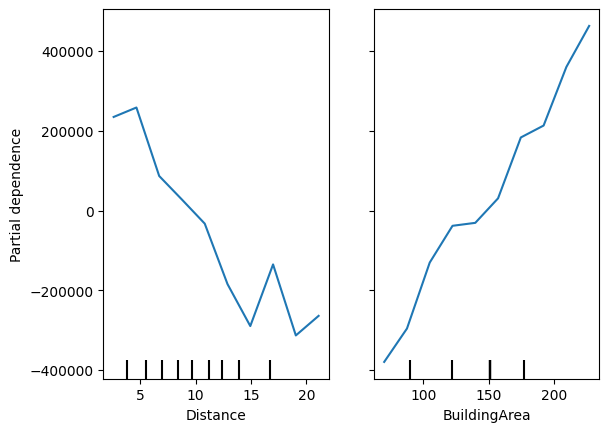

In [26]:
# Using GradientBoostingRegressor on Melbourne Housing data

from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X, y)

PartialDependenceDisplay.from_estimator(
    gbr_model,
    X,
    features=[0, 2],  # 'Distance', 'BuildingArea'
    feature_names=cols_to_use,
    grid_resolution=10
)

The left plot shows the partial dependence between our target, Sales Price, and the distance variable. Distance in this dataset measures the distance to Melbourne's central business district.

**The partial dependence plot is calculated only after the model has been fit.** The model is fit on real data. In that real data, houses in different parts of town may differ in myriad ways (different ages, sizes, etc.) But after the model is fit, we could start by taking all the characteristics of a single house. Say, a house with 2 bedrooms, 2 bathrooms, a large lot, an age of 10 years, etc.

We then use the model to predict the price of that house, but we change the distance variable before making a prediction. We first predict the price for that house when sitting distance to 4. We then predict it's price setting distance to 5. Then predict again for 6. And so on. We trace out how predicted price changes (on the vertical axis) as we move from small values of distance to large values (on the horizontal axis).

In this description, we used only a single house. But because of interactions, the partial dependence plot for a single house may be atypical. So, instead we repeat that mental experiment with multiple houses, and we plot the average predicted price on the vertical axis. You'll see some negative numbers. That doesn't mean the price would sell for a negative price. Instead it means the prices would have been less than the actual average price for that distance.

In the left graph, we see house prices fall as we get further from the central business distract. Though there seems to be a nice suburb about 16 kilometers out, where home prices are higher than many nearer and further suburbs.

The right graph shows the impact of building area, which is interpreted similarly. A larger building area means higher prices.

These plots are useful both to extract insights, as well as to sanity check that your model is learning something you think is sensible.

We could have also used another model, which would show different PDP:

In [ ]:
my_model = LinearRegression()
my_model.fit(X, y)

PartialDependenceDisplay.from_estimator(
    my_model,
    X,
    features=[0, 2],
    feature_names=cols_to_use,
    grid_resolution=10
)

In [14]:
from sklearn.datasets import fetch_openml

titanic = fetch_openml('titanic', version=1, as_frame=True)
df_titanic = titanic.frame

In [16]:
from sklearn.preprocessing import OrdinalEncoder

# Select relevant columns and drop rows with missing target
titanic_data = df_titanic[["age", "fare", "pclass", "sex", "embarked", "survived"]].dropna(subset=["age", "fare", "pclass", "sex", "embarked", "survived"])

X_titanic = titanic_data[["age", "fare", "pclass", "sex", "embarked"]]
y_titanic = titanic_data["survived"].astype(int)

# Encode categorical variables
encoder = OrdinalEncoder()
X_titanic_encoded = X_titanic.copy()
X_titanic_encoded[["pclass", "sex", "embarked"]] = encoder.fit_transform(X_titanic[["pclass", "sex", "embarked"]])

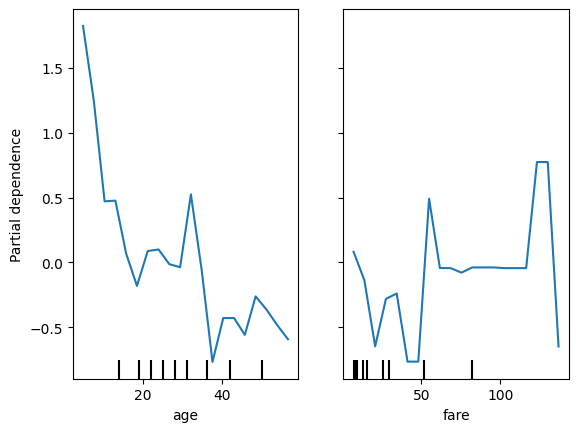

In [24]:
# Using GradientBoostingClassifier on Titanic data

from sklearn.ensemble import GradientBoostingClassifier

gbr_clf = GradientBoostingClassifier(random_state=42)
gbr_clf.fit(X_titanic_encoded, y_titanic)

PartialDependenceDisplay.from_estimator(
    gbr_clf,
    X_titanic_encoded,
    features=[0, 1],  # 'age', 'fare'
    feature_names=X_titanic_encoded.columns,
    grid_resolution=20
)

These might seem surprising at first glance. But they show some interesting insights:

- Being young increased your odds of survival. This is consistent with historical recountings that they got women and children off the Titanic first.
- People who paid more had better odds of survival. It turns out that higher fares got you a cabin that was closer to the top of the boat, and may have given you better odds of getting a life-boat.